In [3]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import cifar100

(x_train, y_train), (x_test, y_test) = cifar100.load_data(label_mode="fine")

print("학습 이미지:", x_train.shape)
print("학습 라벨:", y_train.shape)
print("테스트 이미지:", x_test.shape)
print("테스트 라벨:", y_test.shape)

학습 이미지: (50000, 32, 32, 3)
학습 라벨: (50000, 1)
테스트 이미지: (10000, 32, 32, 3)
테스트 라벨: (10000, 1)


In [4]:
#가구 클래스만 선택
furniture_classes = {
    5: "bed",
    20: "chair",
    25: "couch",
    84: "table",
    94: "wardrobe"
}

class_ids = list(furniture_classes.keys())
class_names = list(furniture_classes.values())

print(class_ids)
print(class_names)

[5, 20, 25, 84, 94]
['bed', 'chair', 'couch', 'table', 'wardrobe']


In [5]:
#가구 데이터 필터링
def filter_furniture_data(x,y):
    y_flat = y.flatten()
    mask = np.isin(y_flat, class_ids)
    
    x_filtered = x[mask]
    y_filtered = y_flat[mask]
    
    return x_filtered, y_filtered

x_train_furniture, y_train_furniture = filter_furniture_data(x_train,y_train)
x_test_furniture, y_test_furniture = filter_furniture_data(x_test,y_test)

print("가구 학습 이미지:", x_train_furniture.shape)
print("가구 학습 라벨:", y_train_furniture.shape)
print("가구 테스트 이미지:", x_test_furniture.shape)
print("가구 테스트 라벨:", y_test_furniture.shape)

가구 학습 이미지: (2500, 32, 32, 3)
가구 학습 라벨: (2500,)
가구 테스트 이미지: (500, 32, 32, 3)
가구 테스트 라벨: (500,)


In [6]:
#라벨 변환(기존에 있는 라벨은 모델 학습에 불편함)
label_map = {
    5: 0,
    20: 1,
    25: 2,
    84: 3,
    94: 4
}

y_train_furniture = np.array([label_map[label] for label in y_train_furniture])
y_test_furniture = np.array([label_map[label] for label in y_test_furniture])

print("변환된 라벨 예시:", y_train_furniture[:20])

변환된 라벨 예시: [3 3 1 3 4 1 1 4 2 0 3 0 1 3 1 0 2 0 1 1]


In [7]:
#이미지 정규화
x_train_furniture = x_train_furniture / 255.0
x_test_furniture = x_test_furniture / 255.0

print("정규화 후 최소값:", x_train_furniture.min())
print("정규화 후 최대값:", x_train_furniture.max())

정규화 후 최소값: 0.0
정규화 후 최대값: 1.0


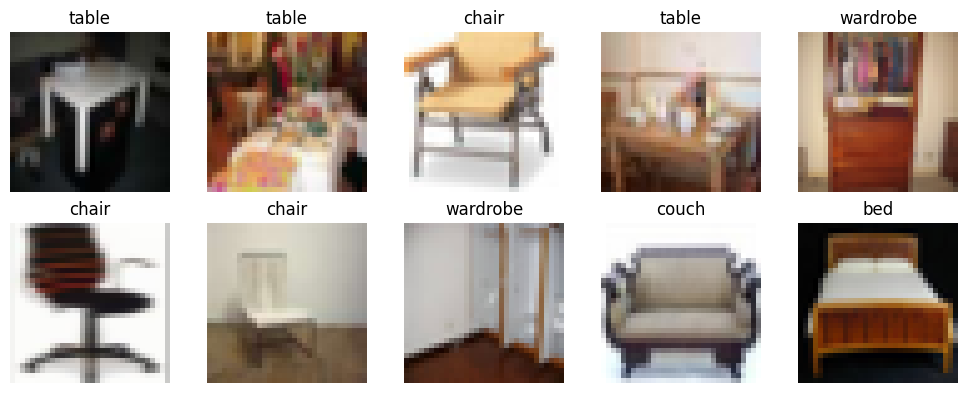

In [8]:
#이미지 샘플 확인
plt.figure(figsize=(10,4))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train_furniture[i])
    plt.title(class_names[y_train_furniture[i]])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [9]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential([
    Conv2D(32, (3, 3), activation="relu", input_shape=(32, 32, 3)),
    MaxPooling2D((2, 2)),

    Conv2D(64, (3, 3), activation="relu"),
    MaxPooling2D((2, 2)),

    Flatten(),
    Dense(128, activation="relu"),
    Dropout(0.3),
    Dense(5, activation="softmax")
])

model.summary()

c:\AIProject\.venv\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 315,077 (1.20 MB)

 Trainable params: 315,077 (1.20 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [11]:
history = model.fit(
    x_train_furniture,
    y_train_furniture,
    epochs=15,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accuracy: 0.3295 - loss: 1.5039 - val_accuracy: 0.4140 - val_loss: 1.3514
Epoch 2/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.4645 - loss: 1.3054 - val_accuracy: 0.5540 - val_loss: 1.1299
Epoch 3/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.5425 - loss: 1.1263 - val_accuracy: 0.5940 - val_loss: 1.0383
Epoch 4/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.5820 - loss: 1.0405 - val_accuracy: 0.6280 - val_loss: 1.0079
Epoch 5/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.6215 - loss: 0.9452 - val_accuracy: 0.6420 - val_loss: 0.9723
Epoch 6/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.6605 - loss: 0.8722 - val_accuracy: 0.6540 - val_loss: 0.9147
Epoch 7/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.6920 - loss: 0.8075 - val_accuracy: 0.6520 - val_loss: 0.9121
Epoch 8/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.6905 - loss: 0.7811 - val_accuracy: 0.6620 - v

In [12]:
test_loss, test_acc = model.evaluate(x_test_furniture, y_test_furniture)

print("테스트 손실:", test_loss)
print("테스트 정확도:", test_acc)

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6280 - loss: 1.0771
테스트 손실: 1.0771050453186035
테스트 정확도: 0.628000020980835


In [ ]:
model.save("models/furniture_cnn.keras")

In [13]:
from tensorflow.keras.models import load_model

model = load_model("models/furniture_cnn.keras")

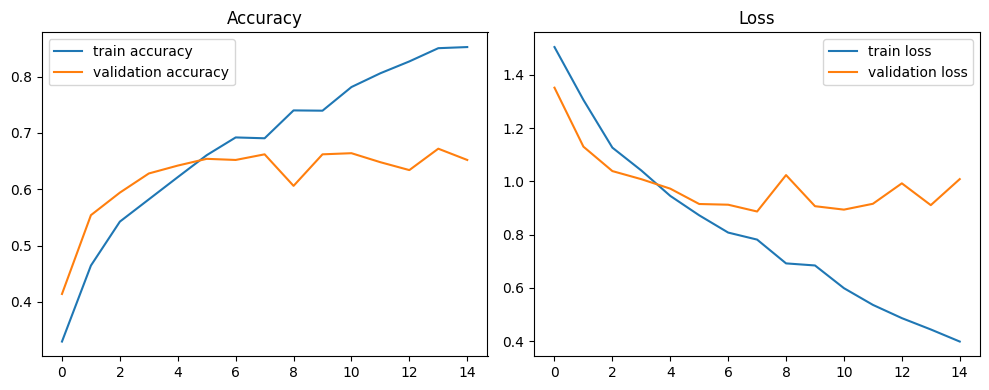

In [14]:
# 학습 과정 그래프 저장
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="train accuracy")
plt.plot(history.history["val_accuracy"], label="validation accuracy")
plt.title("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="train loss")
plt.plot(history.history["val_loss"], label="validation loss")
plt.title("Loss")
plt.legend()

plt.tight_layout()
plt.savefig("outputs/training_history.png", dpi=150)
plt.show()

## 추가 평가 산출물 생성

클래스별 데이터 분포, 혼동행렬, 분류 성능표를 생성하여 보고서와 발표 자료에 활용한다.


In [ ]:
# 추가 평가 산출물 생성
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

output_dir = Path("outputs")
output_dir.mkdir(exist_ok=True)

class_names = ["bed", "chair", "couch", "table", "wardrobe"]
train_counts = pd.Series(y_train_furniture).value_counts().sort_index()
test_counts = pd.Series(y_test_furniture).value_counts().sort_index()

distribution_df = pd.DataFrame({
    "class": class_names,
    "train_count": [train_counts.get(i, 0) for i in range(len(class_names))],
    "test_count": [test_counts.get(i, 0) for i in range(len(class_names))],
})

distribution_df.to_csv(output_dir / "class_distribution.csv", index=False, encoding="utf-8-sig")

plt.figure(figsize=(8, 4))
x = np.arange(len(class_names))
width = 0.35
plt.bar(x - width / 2, distribution_df["train_count"], width, label="train")
plt.bar(x + width / 2, distribution_df["test_count"], width, label="test")
plt.xticks(x, class_names)
plt.ylabel("Count")
plt.title("Furniture Class Distribution")
plt.legend()
plt.tight_layout()
plt.savefig(output_dir / "class_distribution.png", dpi=150)
plt.show()

y_pred_prob = model.predict(x_test_furniture, verbose=0)
y_pred = np.argmax(y_pred_prob, axis=1)

cm = confusion_matrix(y_test_furniture, y_pred)
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.savefig(output_dir / "confusion_matrix.png", dpi=150)
plt.show()

report = classification_report(y_test_furniture, y_pred, target_names=class_names, output_dict=True)
report_df = pd.DataFrame(report).transpose()
report_df.to_csv(output_dir / "classification_report.csv", encoding="utf-8-sig")

print("클래스 분포 저장:", output_dir / "class_distribution.png")
print("혼동행렬 저장:", output_dir / "confusion_matrix.png")
print("분류 성능표 저장:", output_dir / "classification_report.csv")
display(distribution_df)
display(report_df)
